# Homework 2

Датасет тот же, что в первой работе: [TMDB 5000](https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata).

В качестве временного ряда беру среднюю оценку фильмов `vote_average` по месяцам. Дополнительные параметры из файла: средняя длительность фильма, популярность, бюджет и число фильмов за месяц. Беру 200 последовательных месяцев: 160 (80 %) для обучения и 40 (20 %) для проверки.

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA

movies = pd.read_csv("tmdb_5000_movies.csv")
movies["release_date"] = pd.to_datetime(movies["release_date"], errors="coerce")
movies = movies.dropna(subset=["release_date"])
movies["month"] = movies["release_date"].dt.to_period("M")

g = movies.groupby("month").agg(
    y=("vote_average", "mean"),
    runtime=("runtime", "mean"),
    popularity=("popularity", "mean"),
    budget=("budget", "mean"),
    n=("id", "count"),
)

# делаем непрерывную календарную сетку; пропуск получает предыдущее известное значение
g = g.reindex(pd.period_range("1987-01", g.index.max(), freq="M"))
for col in ["y", "runtime", "popularity", "budget"]:
    g[col] = g[col].ffill().bfill()
g["n"] = g["n"].fillna(0)

ts = g.iloc[-200:].copy()
n_train = 160
n_test = 40
y = ts["y"].to_numpy()
y_train, y_test = y[:n_train], y[n_train:]
dates = ts.index.to_timestamp()

print("всего месяцев:", len(ts))
print("train:", n_train, "test:", n_test)
print("период:", ts.index.min(), "—", ts.index.max())
ts.head()

всего месяцев: 200
train: 160 test: 40
период: 2000-07 — 2017-02


,y,runtime,popularity,budget,n
2000-07,5.736364,106.181818,10.616119,4.227273e+07,11.0
2000-08,6.091667,106.666667,13.231785,2.750000e+07,12.0
2000-09,6.109091,106.090909,10.389548,1.252273e+07,22.0
2000-10,6.041176,105.117647,13.779772,2.600588e+07,17.0
2000-11,6.100000,109.777778,23.274133,7.005556e+07,9.0


## 1. Прогноз по предыдущим значениям

Проверяю три способа:

- **ARIMA(1, 1, 1)** учитывает прошлые значения ряда и прошлые ошибки;
- **скользящее среднее** прогнозирует следующее значение как среднее последних пяти;
- **k-NN** ищет в train пять наиболее похожих окон длиной 5.

Для скользящего среднего и k-NN прогноз рекурсивный: рассчитанное значение добавляется в историю и используется на следующем шаге. Ниже выводятся не только размеры массивов, а первые 10 реальных и прогнозных значений.

In [18]:
def forecast_ma(train, steps, window=5):
    history = list(train)
    result = []
    for _ in range(steps):
        value = np.mean(history[-window:])
        result.append(value)
        history.append(value)
    return np.array(result)


def forecast_knn(train, steps, lag=5, k=5):
    X = np.array([train[i - lag:i] for i in range(lag, len(train))])
    Y = train[lag:]
    model = KNeighborsRegressor(n_neighbors=k).fit(X, Y)
    window = list(train[-lag:])
    result = []
    for _ in range(steps):
        value = model.predict([window])[0]
        result.append(value)
        window = window[1:] + [value]
    return np.array(result)


arima = ARIMA(y_train, order=(1, 1, 1)).fit()
pred_arima = np.asarray(arima.forecast(n_test))
pred_ma = forecast_ma(y_train, n_test)
pred_knn = forecast_knn(y_train, n_test)

forecast_values = pd.DataFrame({
    "реальное значение": y_test,
    "ARIMA": pred_arima,
    "скользящее среднее": pred_ma,
    "k-NN": pred_knn,
}, index=dates[n_train:])
forecast_values.head(10).round(3)

,реальное значение,ARIMA,скользящее среднее,k-NN
2013-11-01,6.329,6.036,6.249,5.785
2013-12-01,6.221,6.039,6.252,6.104
2014-01-01,4.718,6.039,6.285,5.979
2014-02-01,6.136,6.039,6.265,6.154
2014-03-01,5.556,6.039,6.239,6.050
2014-04-01,5.317,6.039,6.258,5.971
2014-05-01,5.942,6.039,6.260,5.731
2014-06-01,4.910,6.039,6.261,6.140
2014-07-01,5.731,6.039,6.257,6.075
2014-08-01,5.721,6.039,6.255,6.111


## 2. Однопараметрические модели: МНК и SVR

Искомая величина — `vote_average`, один параметр $x$ — средняя длительность фильма `runtime` за месяц. Для МНК используется указанная в задании формула $y=c_0+c_1x$.

В SVR используется RBF-ядро, поэтому у него нет одной линейной формулы с $c_0$ и $c_1$. Результат модели задают опорные векторы. Вывожу их количество, первые 10 векторов и первые 10 прогнозов обеих моделей.

In [19]:
x1 = ts[["runtime"]].to_numpy()

ols1 = LinearRegression().fit(x1[:n_train], y_train)
pred_ols1 = ols1.predict(x1[n_train:])

sx1, sy1 = StandardScaler(), StandardScaler()
svr1 = SVR(kernel="rbf")
svr1.fit(
    sx1.fit_transform(x1[:n_train]),
    sy1.fit_transform(y_train.reshape(-1, 1)).ravel(),
)
pred_svr1 = sy1.inverse_transform(
    svr1.predict(sx1.transform(x1[n_train:])).reshape(-1, 1)
).ravel()

print("МНК: y = {:.4f} + {:.4f} * runtime".format(ols1.intercept_, ols1.coef_[0]))

pd.DataFrame({
    "реальное значение": y_test,
    "МНК": pred_ols1,
    "SVR": pred_svr1,
}, index=dates[n_train:]).head(10).round(3)

МНК: y = 3.7033 + 0.0222 * runtime


,реальное значение,МНК,SVR
2013-11-01,6.329,6.086,6.169
2013-12-01,6.221,6.255,6.317
2014-01-01,4.718,5.682,5.921
2014-02-01,6.136,6.109,6.189
2014-03-01,5.556,5.941,5.946
2014-04-01,5.317,5.825,5.841
2014-05-01,5.942,5.928,5.931
2014-06-01,4.910,5.977,5.998
2014-07-01,5.731,5.977,5.998
2014-08-01,5.721,6.003,6.042


## 3. Регрессия с двумя параметрами

Добавляю второй параметр из файла — среднюю популярность фильма. Теперь МНК имеет вид
$y=c_0+c_1\cdot runtime+c_2\cdot popularity$. SVR обучается на тех же двух параметрах; для него снова показываю опорные векторы и прогнозы.

In [20]:
x2 = ts[["runtime", "popularity"]].to_numpy()

ols2 = LinearRegression().fit(x2[:n_train], y_train)
pred_ols2 = ols2.predict(x2[n_train:])

sx2, sy2 = StandardScaler(), StandardScaler()
svr2 = SVR(kernel="rbf")
svr2.fit(
    sx2.fit_transform(x2[:n_train]),
    sy2.fit_transform(y_train.reshape(-1, 1)).ravel(),
)
pred_svr2 = sy2.inverse_transform(
    svr2.predict(sx2.transform(x2[n_train:])).reshape(-1, 1)
).ravel()

print("МНК: y = {:.4f} + {:.4f} * runtime + {:.4f} * popularity".format(
    ols2.intercept_, ols2.coef_[0], ols2.coef_[1]
))

pd.DataFrame({
    "реальное значение": y_test,
    "МНК": pred_ols2,
    "SVR": pred_svr2,
}, index=dates[n_train:]).head(10).round(3)

МНК: y = 3.8658 + 0.0192 * runtime + 0.0073 * popularity


,реальное значение,МНК,SVR
2013-11-01,6.329,6.155,6.226
2013-12-01,6.221,6.268,6.305
2014-01-01,4.718,5.734,5.922
2014-02-01,6.136,6.179,6.239
2014-03-01,5.556,6.002,5.977
2014-04-01,5.317,5.837,5.766
2014-05-01,5.942,6.017,6.087
2014-06-01,4.910,6.070,6.192
2014-07-01,5.731,6.273,6.153
2014-08-01,5.721,6.078,6.167


## 4–5. Графики, MAE и RMSE

На каждом графике показаны исходные 160 месяцев, реальные 40 месяцев теста и прогноз. MAE показывает среднюю абсолютную ошибку, RMSE сильнее штрафует большие ошибки. Чем меньше обе метрики, тем лучше.

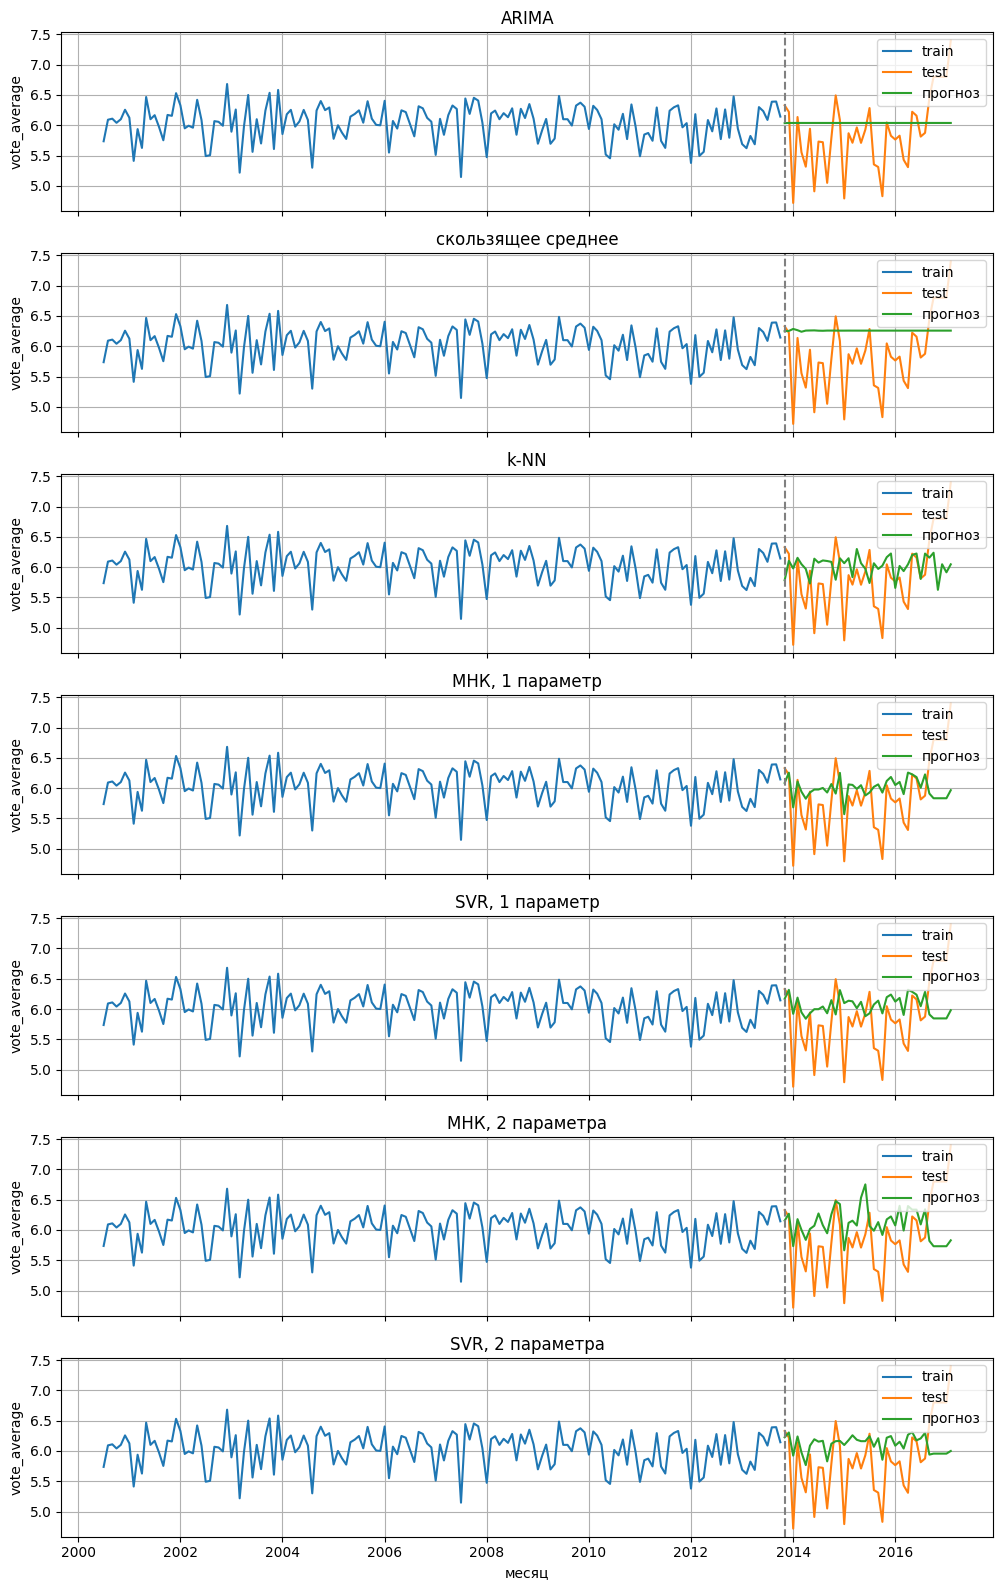

,MAE,RMSE
"МНК, 1 параметр",0.4771,0.6075
ARIMA,0.4841,0.6168
"SVR, 2 параметра",0.5233,0.6446
k-NN,0.5104,0.6484
"SVR, 1 параметр",0.5242,0.6536
"МНК, 2 параметра",0.5684,0.6890
скользящее среднее,0.5730,0.7078


лучшая модель по RMSE: МНК, 1 параметр


In [21]:
models = {
    "ARIMA": pred_arima,
    "скользящее среднее": pred_ma,
    "k-NN": pred_knn,
    "МНК, 1 параметр": pred_ols1,
    "SVR, 1 параметр": pred_svr1,
    "МНК, 2 параметра": pred_ols2,
    "SVR, 2 параметра": pred_svr2,
}

fig, axes = plt.subplots(len(models), 1, figsize=(10, 16), sharex=True)
for ax, (name, prediction) in zip(axes, models.items()):
    ax.plot(dates[:n_train], y_train, label="train")
    ax.plot(dates[n_train:], y_test, label="test")
    ax.plot(dates[n_train:], prediction, label="прогноз")
    ax.axvline(dates[n_train], color="gray", linestyle="--")
    ax.grid(True)
    ax.set_ylabel("vote_average")
    ax.set_title(name)
    ax.legend(loc="upper right")
axes[-1].set_xlabel("месяц")
plt.tight_layout()
plt.show()


def scores(real, prediction):
    return {
        "MAE": mean_absolute_error(real, prediction),
        "RMSE": mean_squared_error(real, prediction) ** 0.5,
        "R2": r2_score(real, prediction),
    }


base_scores = pd.DataFrame({
    name: scores(y_test, prediction) for name, prediction in models.items()
}).T
display(base_scores[["MAE", "RMSE"]].sort_values("RMSE").round(4))
print("лучшая модель по RMSE:", base_scores["RMSE"].idxmin())

**Вывод по базовой части.** Ряд месячных оценок шумный, поэтому прогнозы в основном стремятся к среднему уровню. По таблице видно, какая модель дала минимальные MAE и RMSE. Добавление второго параметра нужно оценивать по тестовой ошибке: более сложная модель не обязательно точнее.

## Дополнительная часть +1: Lasso и PLS

Для многопараметрических моделей используется четыре параметра из файла: `runtime`, `popularity`, `budget` и число фильмов `n`. Все признаки стандартизируются только по train. Lasso зануляет слабые коэффициенты, а PLS строит две скрытые компоненты. Сравнение со всеми базовыми моделями выполняется по $R^2$.

In [22]:
xm = ts[["runtime", "popularity", "budget", "n"]].to_numpy()
sxm = StandardScaler()
xm_train = sxm.fit_transform(xm[:n_train])
xm_test = sxm.transform(xm[n_train:])

lasso = Lasso(alpha=0.01).fit(xm_train, y_train)
pls = PLSRegression(n_components=2).fit(xm_train, y_train)
pred_lasso = lasso.predict(xm_test)
pred_pls = pls.predict(xm_test).ravel()

print("коэффициенты Lasso:")
display(pd.Series(lasso.coef_, index=["runtime", "popularity", "budget", "n"]).round(4))
print("первые 10 прогнозов:")
display(pd.DataFrame({
    "реальное значение": y_test,
    "Lasso": pred_lasso,
    "PLS": pred_pls,
}, index=dates[n_train:]).head(10).round(3))

extra_models = {**models, "Lasso": pred_lasso, "PLS": pred_pls}
extra_scores = pd.DataFrame({
    name: scores(y_test, prediction) for name, prediction in extra_models.items()
}).T.sort_values("R2", ascending=False)
extra_scores.round(4)

коэффициенты Lasso:


runtime       0.1257
popularity    0.0854
budget       -0.0432
n             0.0426
dtype: float64

первые 10 прогнозов:


,реальное значение,Lasso,PLS
2013-11-01,6.329,6.194,6.134
2013-12-01,6.221,6.311,6.363
2014-01-01,4.718,5.792,5.781
2014-02-01,6.136,6.146,6.109
2014-03-01,5.556,6.004,6.007
2014-04-01,5.317,5.857,5.835
2014-05-01,5.942,6.049,6.042
2014-06-01,4.910,6.139,6.119
2014-07-01,5.731,6.457,6.326
2014-08-01,5.721,6.202,6.185


,MAE,RMSE,R2
"МНК, 1 параметр",0.4771,0.6075,-0.0415
ARIMA,0.4841,0.6168,-0.0737
"SVR, 2 параметра",0.5233,0.6446,-0.1725
k-NN,0.5104,0.6484,-0.1864
"SVR, 1 параметр",0.5242,0.6536,-0.2055
"МНК, 2 параметра",0.5684,0.6890,-0.3396
скользящее среднее,0.5730,0.7078,-0.4138
PLS,0.6263,0.7698,-0.6724
Lasso,0.6401,0.7719,-0.6813


**Вывод +1.** Лучшее значение $R^2$ находится в верхней строке таблицы. Если $R^2<0$, модель на этом тесте хуже простого прогноза средним значением. Поэтому Lasso и PLS считаю улучшением только в случае, если они поднялись выше моделей базовой части.

## Дополнительная часть +2: размер обучающей выборки

Оставляю один и тот же тест из последних 40 месяцев и сравниваю три модели временного прогноза при train 80, 160 и 320 месяцев. Так меняется только количество обучающих данных, а тест остаётся одинаковым.

MAE:


/Users/s.sidorov/Library/Python/3.9/lib/python/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


train,80,160,320
модель,,,
ARIMA,0.4792,0.4841,0.4793
k-NN,0.5040,0.5104,0.5061
скользящее среднее,0.5730,0.5730,0.5730


RMSE:


train,80,160,320
модель,,,
ARIMA,0.6122,0.6168,0.6121
k-NN,0.6245,0.6484,0.6458
скользящее среднее,0.7078,0.7078,0.7078


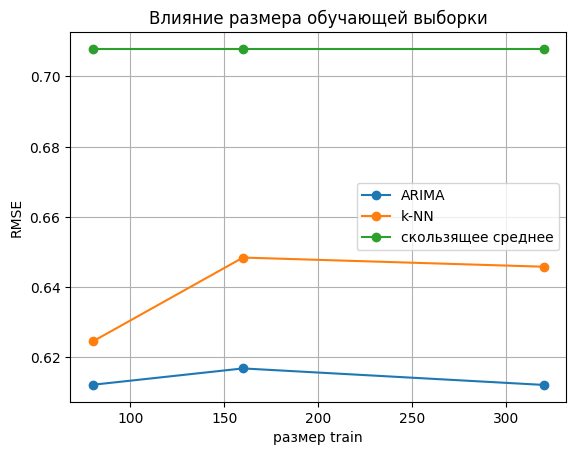

In [23]:
size_rows = []
for train_size in [80, 160, 320]:
    part = g.iloc[-(train_size + n_test):]
    train = part["y"].to_numpy()[:train_size]
    test = part["y"].to_numpy()[train_size:]
    predictions = {
        "ARIMA": np.asarray(ARIMA(train, order=(1, 1, 1)).fit().forecast(n_test)),
        "скользящее среднее": forecast_ma(train, n_test),
        "k-NN": forecast_knn(train, n_test),
    }
    for name, prediction in predictions.items():
        row = scores(test, prediction)
        size_rows.append({"train": train_size, "модель": name, **row})

size_scores = pd.DataFrame(size_rows)
print("MAE:")
display(size_scores.pivot(index="модель", columns="train", values="MAE").round(4))
print("RMSE:")
display(size_scores.pivot(index="модель", columns="train", values="RMSE").round(4))

for name, group in size_scores.groupby("модель"):
    plt.plot(group["train"], group["RMSE"], marker="o", label=name)
plt.grid(True)
plt.xlabel("размер train")
plt.ylabel("RMSE")
plt.title("Влияние размера обучающей выборки")
plt.legend()
plt.show()

## Дополнительная часть +2: предыдущее расчётное значение

К тем же четырём признакам Lasso и PLS добавляются $y_{t-1}$. На train это реальное предыдущее значение, а на test — прогноз предыдущего шага. Набор остальных признаков не меняется, поэтому сравнение «без лага / с лагом» корректное.

,MAE,RMSE,R2
PLS без лага,0.6263,0.7698,-0.6724
Lasso без лага,0.6401,0.7719,-0.6813
PLS с лагом,0.6290,0.7734,-0.6878
Lasso с лагом,0.6416,0.7736,-0.6887


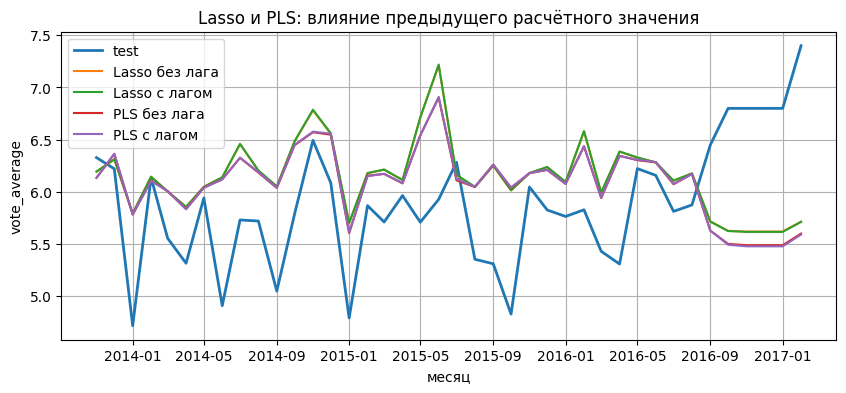

In [24]:
def recursive_lag(kind):
    lag_train = np.r_[y_train[0], y_train[:-1]]
    x_train = np.column_stack([xm[:n_train], lag_train])
    scaler = StandardScaler()
    x_train = scaler.fit_transform(x_train)

    if kind == "Lasso":
        model = Lasso(alpha=0.01).fit(x_train, y_train)
    else:
        model = PLSRegression(n_components=2).fit(x_train, y_train)

    previous = y_train[-1]
    result = []
    for i in range(n_test):
        row = np.r_[xm[n_train + i], previous].reshape(1, -1)
        value = np.ravel(model.predict(scaler.transform(row)))[0]
        result.append(value)
        previous = value
    return np.array(result)


pred_lasso_lag = recursive_lag("Lasso")
pred_pls_lag = recursive_lag("PLS")

lag_models = {
    "Lasso без лага": pred_lasso,
    "Lasso с лагом": pred_lasso_lag,
    "PLS без лага": pred_pls,
    "PLS с лагом": pred_pls_lag,
}
lag_scores = pd.DataFrame({
    name: scores(y_test, prediction) for name, prediction in lag_models.items()
}).T.sort_values("RMSE")
display(lag_scores.round(4))

plt.figure(figsize=(10, 4))
plt.plot(dates[n_train:], y_test, label="test", linewidth=2)
for name, prediction in lag_models.items():
    plt.plot(dates[n_train:], prediction, label=name)
plt.grid(True)
plt.xlabel("месяц")
plt.ylabel("vote_average")
plt.title("Lasso и PLS: влияние предыдущего расчётного значения")
plt.legend()
plt.show()

## Итог

Сначала сравниваются модели прогноза по прошлым значениям, затем регрессии с одним и двумя параметрами, после этого Lasso и PLS. Таблицы показывают не только итоговую ошибку, но и сами первые прогнозы. В дополнительной части отдельно проверено влияние размера train и расчётного лага. Окончательный выбор модели делается по минимальным MAE/RMSE и максимальному $R^2$, а не по сложности модели.